To demonstrate ``AAPredPlot().eval()``, we build a feature matrix and evaluate a model with a held-out set:

In [1]:
import aaanalysis as aa
aa.options["verbose"] = False  # Disable verbosity

# DOM_GSEC example dataset + its feature set (see [Breimann25]_)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_feat = aa.load_features(name="DOM_GSEC").head(20)

# Build the CPP feature matrix
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

from sklearn.model_selection import train_test_split
X_tr, X_ho, y_tr, y_ho = train_test_split(X, labels, test_size=0.3, random_state=0, stratify=labels)
aapred = aa.AAPred(random_state=42)
df_eval = aapred.eval(X_tr, y_tr, X_holdout=X_ho, labels_holdout=y_ho)

/Users/stephanbreimann/Programming/1Packages/wt-prediction-class/aaanalysis/feature_engineering/_backend/cpp_run.py:164: UserWarning: CPP is using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.
  warnings.warn(


Bars are grouped by metric and colored by model; held-out bars are hatched and a baseline line marks chance:

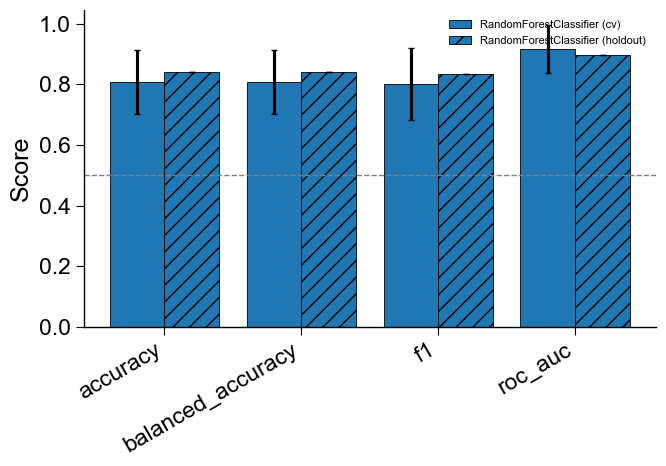

In [2]:
import matplotlib.pyplot as plt
aa.plot_settings()
aapred_plot = aa.AAPredPlot()
aapred_plot.eval(df_eval, baseline=0.5)
plt.tight_layout()
plt.show()